In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
import xgboost as xgb

In [2]:
df = pd.read_csv('obesity_data.csv')

In [3]:
df.head()

,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,Male,173.575262,71.982051,23.891783,4,Normal weight
1,69,Male,164.127306,89.959256,33.395209,2,Obese
2,46,Female,168.072202,72.930629,25.817737,4,Overweight
3,32,Male,168.459633,84.886912,29.912247,3,Overweight
4,60,Male,183.568568,69.038945,20.487903,3,Normal weight


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Gender                 1000 non-null   object 
 2   Height                 1000 non-null   float64
 3   Weight                 1000 non-null   float64
 4   BMI                    1000 non-null   float64
 5   PhysicalActivityLevel  1000 non-null   int64  
 6   ObesityCategory        1000 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 54.8+ KB


,Age,Height,Weight,BMI,PhysicalActivityLevel
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.857000,170.052417,71.205769,24.888317,2.534000
std,18.114267,10.309971,15.509849,6.193912,1.116284
min,18.000000,136.115719,26.065730,8.470572,1.000000
25%,35.000000,163.514205,61.129629,20.918068,2.000000
50%,50.000000,169.801665,71.929072,24.698647,3.000000
75%,66.000000,177.353596,81.133746,28.732132,4.000000
max,79.000000,201.419670,118.907366,50.791898,4.000000


In [5]:
df['ObesityCategory'].value_counts()

ObesityCategory
Normal weight    371
Overweight       295
Obese            191
Underweight      143
Name: count, dtype: int64

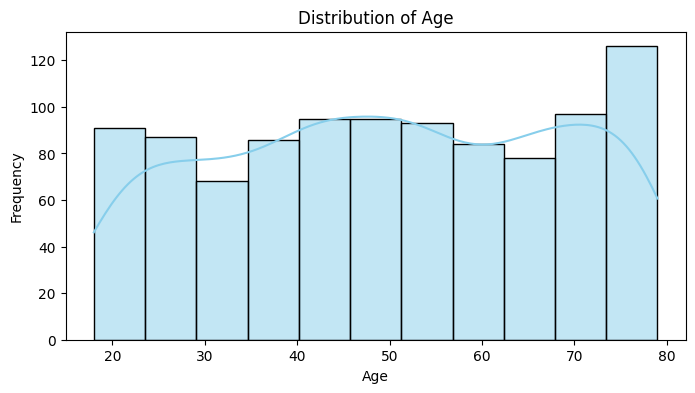

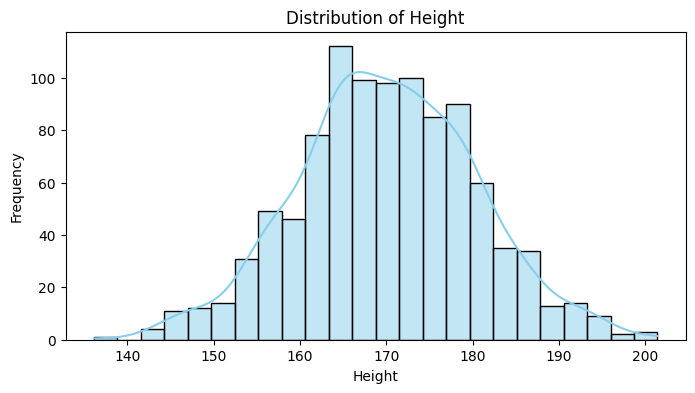

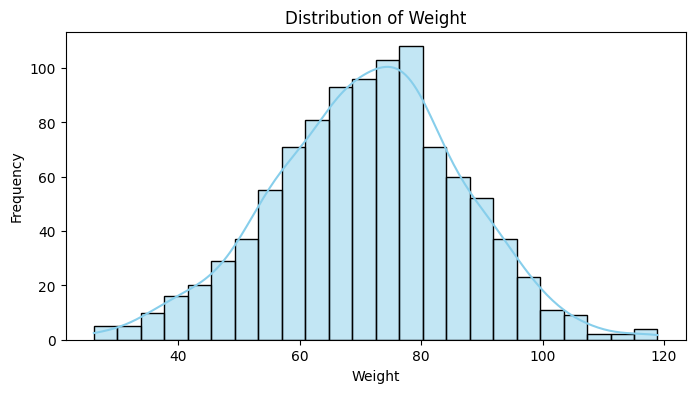

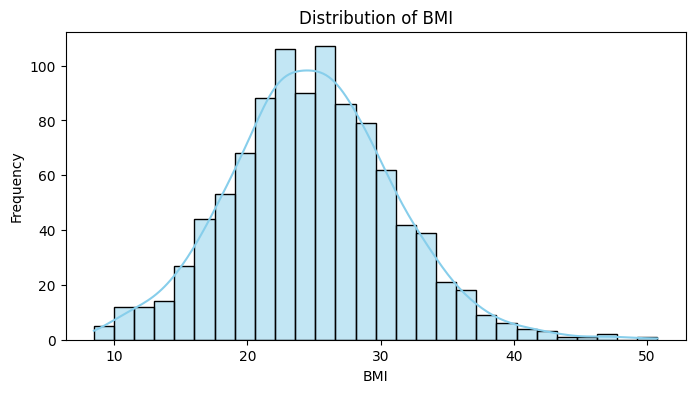

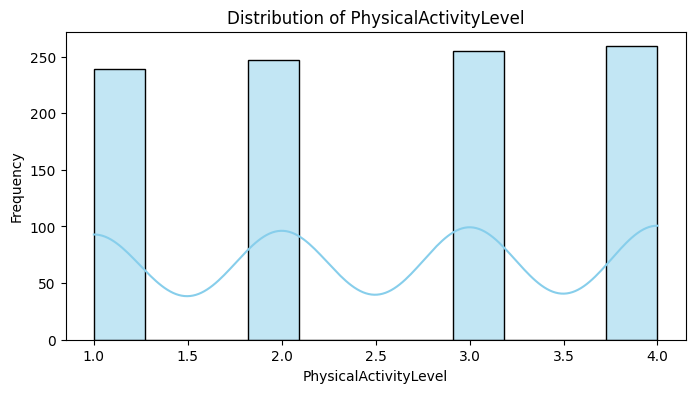

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns
skew_vals = df[numeric_cols].skew()
print("Skewness:\n", skew_vals)

Skewness:
 Age                     -0.065755
Height                   0.009357
Weight                  -0.090733
BMI                      0.252872
PhysicalActivityLevel   -0.042192
dtype: float64


In [8]:
skewed_cols = skew_vals[abs(skew_vals) > 1].index
for col in skewed_cols:

    if (df[col] > 0).all():
        df[col] = np.log1p(df[col])

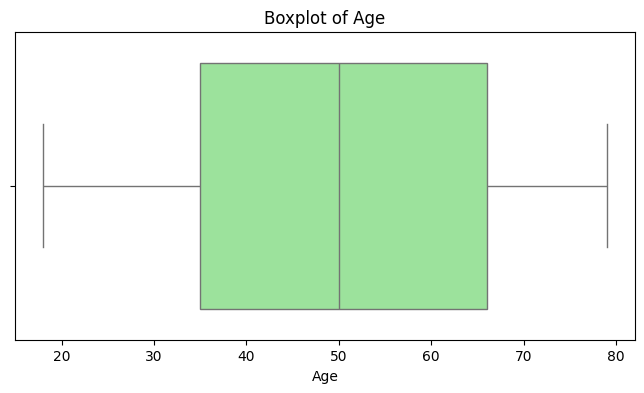

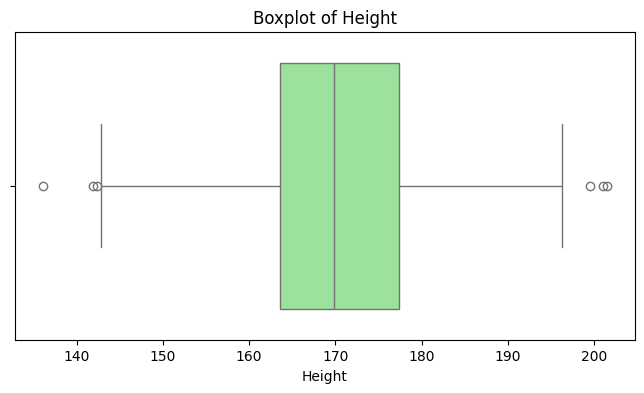

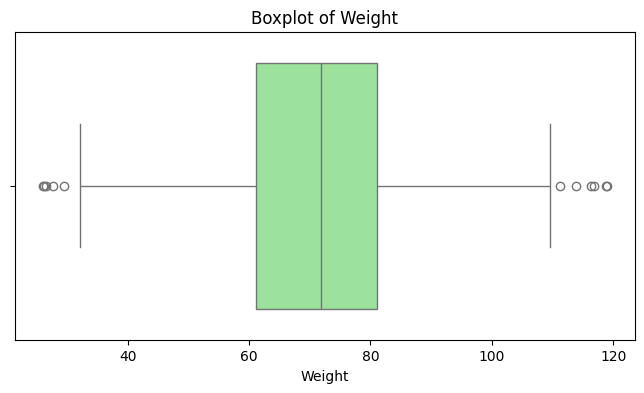

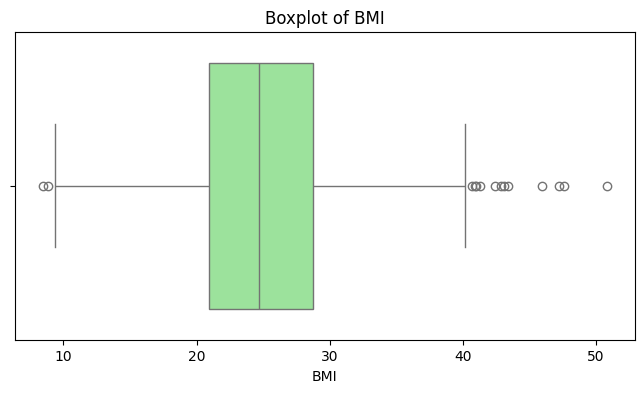

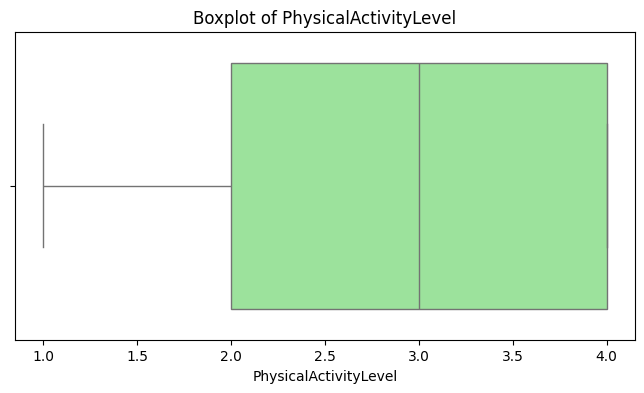

In [9]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [10]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR)))
    df = df[~outliers]


In [11]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if col != 'ObesityCategory':
        df[col] = LabelEncoder().fit_transform(df[col])


In [12]:
from sklearn.preprocessing import LabelEncoder

df['ObesityCategory'] = LabelEncoder().fit_transform(df['ObesityCategory'])


In [13]:
df.head()

,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,1,173.575262,71.982051,23.891783,4,0
1,69,1,164.127306,89.959256,33.395209,2,1
2,46,0,168.072202,72.930629,25.817737,4,2
3,32,1,168.459633,84.886912,29.912247,3,2
4,60,1,183.568568,69.038945,20.487903,3,0


In [14]:
X = df.drop('ObesityCategory', axis=1)
y = df['ObesityCategory']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

In [17]:
models = {
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes (Gaussian)": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

Model: Random Forest
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        59
           3       1.00      1.00      1.00        27

    accuracy                           1.00       195
   macro avg       1.00      1.00      1.00       195
weighted avg       1.00      1.00      1.00       195



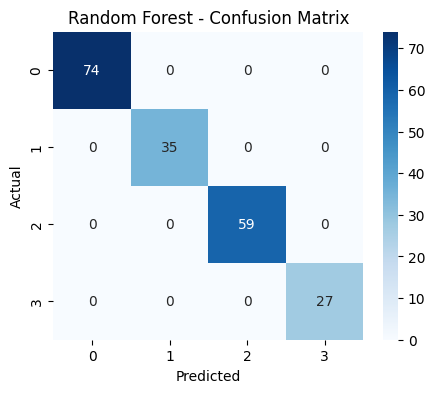

Model: AdaBoost
Accuracy: 0.31794871794871793
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       1.00      1.00      1.00        35
           2       0.00      0.00      0.00        59
           3       0.17      1.00      0.29        27

    accuracy                           0.32       195
   macro avg       0.29      0.50      0.32       195
weighted avg       0.20      0.32      0.22       195



c:\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


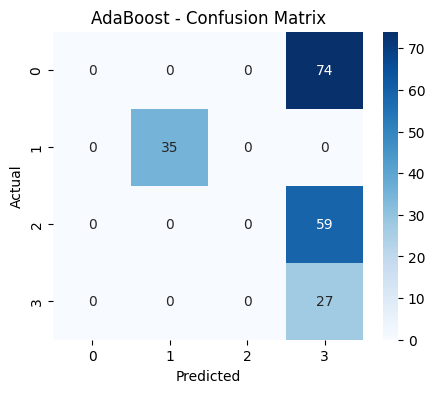

Model: Naive Bayes (Gaussian)
Accuracy: 0.9846153846153847
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        74
           1       1.00      1.00      1.00        35
           2       0.98      0.98      0.98        59
           3       1.00      0.96      0.98        27

    accuracy                           0.98       195
   macro avg       0.99      0.98      0.99       195
weighted avg       0.98      0.98      0.98       195



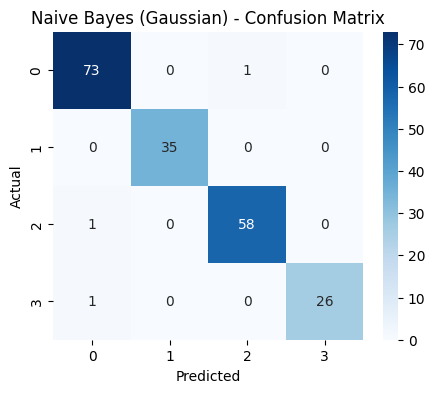

Model: Decision Tree
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        59
           3       1.00      1.00      1.00        27

    accuracy                           1.00       195
   macro avg       1.00      1.00      1.00       195
weighted avg       1.00      1.00      1.00       195



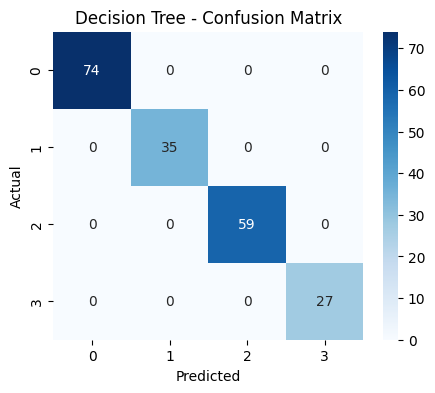

c:\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: Logistic Regression
Accuracy: 0.9846153846153847
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        74
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        59
           3       1.00      0.89      0.94        27

    accuracy                           0.98       195
   macro avg       0.99      0.97      0.98       195
weighted avg       0.99      0.98      0.98       195



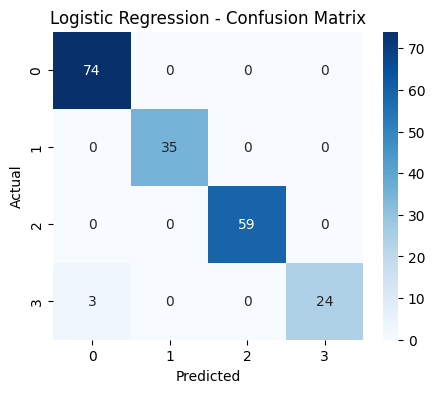

c:\Python314\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:36:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XGBoost
Accuracy: 0.9897435897435898
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        74
           1       1.00      1.00      1.00        35
           2       0.98      1.00      0.99        59
           3       0.96      1.00      0.98        27

    accuracy                           0.99       195
   macro avg       0.99      0.99      0.99       195
weighted avg       0.99      0.99      0.99       195



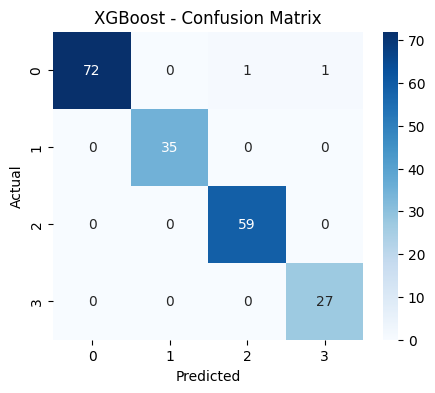

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


    acc = accuracy_score(y_test, y_pred)
    print(f"Model: {name}")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))


    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results[name] = acc

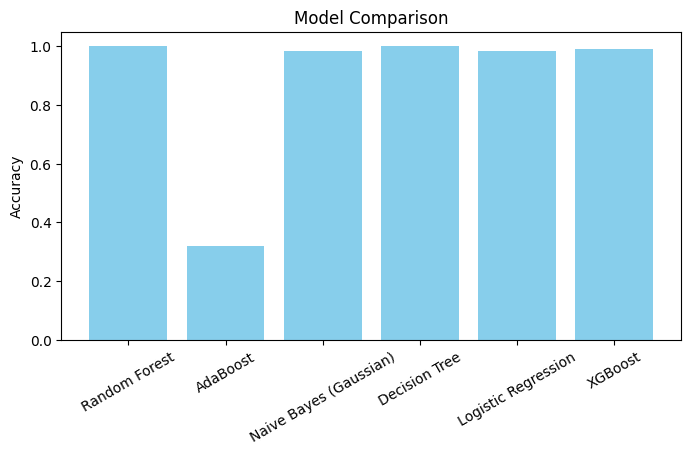

In [19]:
plt.figure(figsize=(8,4))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()